<a href="https://colab.research.google.com/github/pc-repo/algorytmy-ewolucyjne/blob/main/AE_L7_65456.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AE_Lab_7**
Wspomaganie procesów optymalizacyjnych z wykorzystaniem algorytmów rojowych

---

###**Zad. 1.** Korzystając z biblioteki *pyswarms* napisz i przetestuj algorytm rojowy (**PSO**) do poszukiwania maximum funkcji Rastrigina. Zmianę wartości funkcji celu przedstaw na wykresie, a zachowanie się cząsteczek w kolejnych iteracjach przy pomocy animacji.

In [ ]:
# instalacja biblioteki
!pip install pyswarms

In [ ]:
# Potrzebne importy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from pyswarms.single.global_best import GlobalBestPSO
from pyswarms.utils.functions.single_obj import rastrigin as fx

In [ ]:
# Parametry rojowe algorytmu
# C1 -> wpływ najlepszego rozwiązania osobnika - C1(0, 5)
# C2 -> wpływ najlepszego rozwiązania globalnego - C2(0, 5)
# W  -> bezwładność ruchu cząstki (osobnika) - W(0,1)

options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}    # Powszechnie stosowane wartości
dimension = 2
n_particles = 15
iterations = 30

In [ ]:
# Tworzenie "solwera" PSO (biblioteka pyswarms) wg. zadanych parametrów
optimizer = GlobalBestPSO(n_particles=n_particles, dimensions=dimension, options=options)


# Funkcja Rastrigina (globalne opimum oraz odpowiadająca funkcja celu)
cost, pos = optimizer.optimize(fx, iters=iterations)


print("Najlepsze rozwiązanie: ", pos)
print("Oodpowiadająca funkcja celu: ", cost)

2025-06-13 18:21:37,091 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.0176
2025-06-13 18:21:37,181 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.017550482959741487, best pos: [0.00336326 0.00878476]


Najlepsze rozwiązanie:  [0.00336326 0.00878476]
Oodpowiadająca funkcja celu:  0.017550482959741487


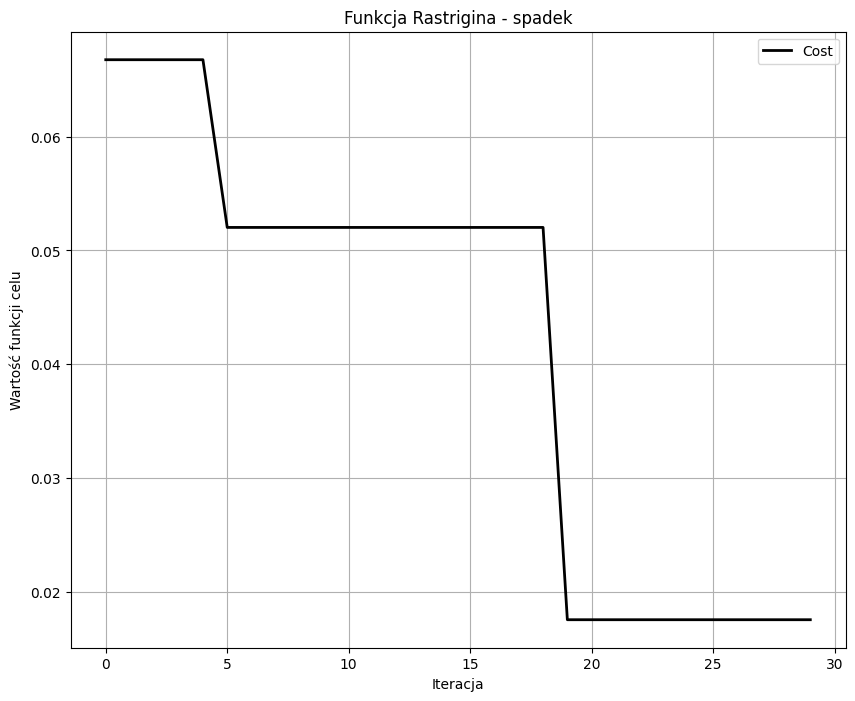

In [ ]:
# Przygotowanie wykresu zbieżności (spadek kosztu)
from pyswarms.utils.plotters import plot_cost_history
plot_cost_history(optimizer.cost_history)
plt.title("Funkcja Rastrigina - spadek")
plt.xlabel("Iteracja")
plt.ylabel("Wartość funkcji celu")
plt.grid(True)
plt.show()

In [ ]:
# Zapisywanie pozycji
pos_history = np.array(optimizer.pos_history)

In [ ]:
# Część obliczeniowa

import matplotlib.animation as animation
from pyswarms.utils.functions.single_obj import rastrigin as fx

# Przygotowanie wykresu
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-5.5, 5.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
scat = ax.scatter([], [], c = 'blue')

best_marker, = ax.plot([], [], 'r*', markersize=12, label='Najlepsze rozwiązanie')

# Definicja stanu początkowego (pustego)
def init():
    scat.set_offsets(np.zeros((n_particles, 2)))
    best_marker.set_data([], [])
    return scat, best_marker

# Przygotowanie animacji - poklatkowo dla kolejnych iteracj
def update(frame):
   positions = pos_history[frame]
   scat.set_offsets(positions)

   # Najlepsza jak dotąd iteracja
   cost_values = optimizer.cost_history[:frame + 1]
   best_iter_index = np.argmin(cost_values)

   # Poszukiwanie najlepiej dopasowanej cząstki
   particles = optimizer.pos_history[best_iter_index]
   costs = fx(particles)
   best_particle_index = np.argmin(costs)
   best_pos = particles[best_particle_index]


   # Najlepiej dopasowane rozwiązanie
   best_marker.set_data([best_pos[0]], [best_pos[1]])

   ax.set_title(f'Iteracja: {frame + 1}')
   ax.legend()
   return scat, best_marker

# Przygotowanie parametrów animacji
anim = animation.FuncAnimation(fig, update, frames=iterations, init_func=init, blit=True, repeat = False)
plt.close(fig)

# Konwersja animacji na format HTML i wyświetlanie
HTML(anim.to_jshtml())

2025-06-13 18:21:50,250 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.HTMLWriter'>


###**Zad. 2.** Zbadaj przebieg zmian wartości funkcji celu od wybranego parametru zadeklarowanego w options i przedstaw go nawykresie.

Kod jest duplikacją kodu z zadania 1. Jedyną zmianą zgodnie z treścią do zadania 2, jest zmiana współczynnika bezwładności cząstek.

Na wykresie widać wyraźnie ograniczenie (spowolnienie) ruchu rojowego. Parametr 'W' został zmieniony z wartości bliskiej maksimum (0.9) do bliskiej minimum (0.1).

Zmienił się także przebieg funkcji celu. Zbieżność jest osiągana znacznie wcześniej a jej kształt jest bardziej gładki.

In [ ]:
# Parametry rojowe algorytmu
# C1 -> wpływ najlepszego rozwiązania osobnika - C1(0, 5)
# C2 -> wpływ najlepszego rozwiązania globalnego - C2(0, 5)
# W  -> bezwładność ruchu cząstki (osobnika) - W(0,1)

# W parametrach zmieniłem wartość w(0.9) na w(0.1)
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.1}

In [ ]:
!pip install pyswarms

In [ ]:
# Potrzebne importy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from pyswarms.single.global_best import GlobalBestPSO
from pyswarms.utils.functions.single_obj import rastrigin as fx

# Deklaracje pozostałych stałych
dimension = 2
n_particles = 15
iterations = 30

2025-06-13 18:57:48,467 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': np.float64(0.1)}


Testowanie wpływu parametru 'w' na funkcję celu dla 10 wartości...


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=6.13
2025-06-13 18:57:48,510 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 6.131880915254506, best pos: [0.16201688 0.95207065]
2025-06-13 18:57:48,518 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': np.float64(0.18888888888888888)}


Dla w=0.10: Najlepszy koszt = 6.1319


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=2.37
2025-06-13 18:57:48,550 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 2.3687477548228486, best pos: [0.05201432 0.92919689]
2025-06-13 18:57:48,560 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': np.float64(0.2777777777777778)}


...

Dla w=0.72: Najlepszy koszt = 1.9900


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=1.13
2025-06-13 18:57:48,839 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 1.1286806213823226, best pos: [1.01077914 0.02060088]
2025-06-13 18:57:48,848 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': np.float64(0.9)}


Dla w=0.81: Najlepszy koszt = 1.1287


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.997
2025-06-13 18:57:48,883 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.9973922493760163, best pos: [0.00177093 0.99193621]


Dla w=0.90: Najlepszy koszt = 0.9974


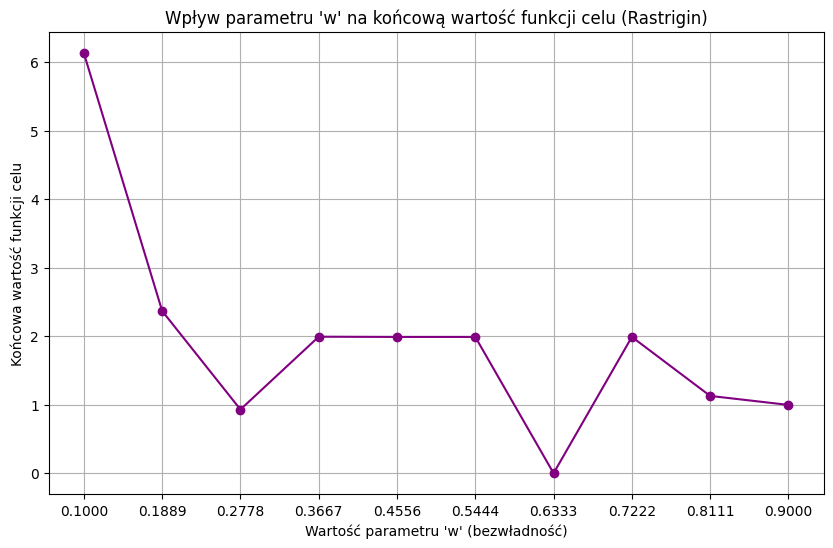

In [ ]:
w_values = np.linspace(0.1, 0.9, 10) # 10 równo rozłożonych wartości 'w' od 0.1 do 0.9
final_costs = [] # Lista do przechowywania końcowych wartości funkcji celu dla każdego 'w'

print(f"Testowanie wpływu parametru 'w' na funkcję celu dla {len(w_values)} wartości...")

for w in w_values:
    # Ustawienie opcji dla bieżącej wartości 'w'
    options = {'c1': 0.5, 'c2': 0.3, 'w': w}

    # Tworzenie "solwera" PSO (biblioteka pyswarms) dla bieżących opcji
    optimizer = GlobalBestPSO(n_particles=n_particles, dimensions=dimension, options=options)

    # Optymalizacja funkcji Rastrigina
    cost, pos = optimizer.optimize(fx, iters=iterations)
    final_costs.append(cost) # Zapisz końcowy koszt

    print(f"Dla w={w:.2f}: Najlepszy koszt = {cost:.4f}")

# --- Wykres zmienności parametru 'W' w funkcji celu ---
plt.figure(figsize=(10, 6))
plt.plot(w_values, final_costs, marker='o', linestyle='-', color='purple')
plt.title("Wpływ parametru 'w' na końcową wartość funkcji celu (Rastrigin)")
plt.xlabel("Wartość parametru 'w' (bezwładność)")
plt.ylabel("Końcowa wartość funkcji celu")
plt.grid(True)
plt.xticks(w_values) # Ustawienie znaczników na osi X dla każdej testowanej wartości 'w'
plt.show()

Na wykresie widać wyraźnie ograniczenie (spowolnienie) ruchu rojowego. Parametr 'W' został zmieniony z wartości bliskiej maksimum do bliskiej minimum.

Zmienił się także przebieg funkcji celu. Zbieżność jest osiągana wcześniej a jej kształt jest bardziej gładki.

###**Zad. 3.** Korzystając z biblioteki *pyswarms* napisz i przetestuj algorytm rojowy (**PSO**) do poszukiwania optymalnego rozstawienia routerów WiFi na powierzchni hali targowej. Zmianę wartości funkcji celu przedstaw na wykresie, a zachowanie się cząsteczek w kolejnych iteracjach przy pomocy animacji.

Jako, że nie zostały podane parametry rozmiaru obszaru ani ilości routerów, ilość tę dobrałem metodą kolejnych prób. Dla obszaru 50 x 50 optymalna ilość, mająca szansę pokrycia całego obszaru to 10 routerów. Taki dobór parametru pokazuje dokładność metody, gdzie routery rzeczywiście pokrywają cały obszar, praktycznie bez nałożeń.

Ilość iteracji ustawiłem na 40, co jest wystarczające i pozwala znaleźć optymalne rozwiązanie. Właśnie dokładnie około 40 iteracji animacja wskazuje najlepszy wynik działania algorytmu.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle
from IPython.display import HTML

# Parametry budynku i zasięgu
grid_size = 50
coverage_radius = 10
num_routers = 10
max_iter = 40
dimension = num_routers * 2
bounds = [(0, grid_size) for _ in range(dimension)]

# Definicja pokrycia zasięgiem (ujemna mapa pokrycia)
def wifi_coverage_score(positions):
  positions = np.reshape(positions, (num_routers, 2))   # Definicja pozycji
  coverage_map = np.zeros((grid_size, grid_size))       # Inicjacja mapy (zera)

  for x in range(grid_size):                            # Przejście po całym obszarze (siatce)
    for y in range(grid_size):
      # Ile routerów pokrywa dany punkt
      count = sum(np.hypot(x - rx, y - ry) < coverage_radius for rx, ry in positions)
      if count > 0:
        coverage_map[x, y] = 1
      if count > 1:
        coverage_map[x, y] = 0.5

  return -np.sum(coverage_map)          # Funkcja celu ze znakiem "-", szukamy maksymalizacji pokrycia

In [ ]:
# Definicja klasy cząstki
class Particle:

  # Inicjacja losowa - pozycja, prędkość, najlepsza pozycja, początkowy wynik
  def __init__(self, bounds):
    self.position = np.array([np.random.uniform(low, high) for low, high in bounds])
    self.velocity = np.random.uniform(-1, 1, len(bounds))
    self.best_position = np.copy(self.position)
    self.best_score = wifi_coverage_score(self.position)

  # Aktualizacja prędkości - czynnik własny oraz globalny
  def update_velocity(self, global_best_position, w = 0.5, c1 = 1.5, c2 = 1.5):
    r1 = np.random.random(len(self.position))
    r2 = np.random.random(len(self.position))
    cognitive = c1 * r1 * (self.best_position - self.position)  # Czynnik własny
    social = c2 * r2 * (global_best_position - self.position)   # Czynnik globalny
    self.velocity = w * self.velocity + cognitive + social      # Aktualizacja wartości

  # Zmiana położenia, nadanie kierunku zgodnie z prędkością
  def update_position(self, bounds):
    self.position += self.velocity
    for i, (low, high) in enumerate(bounds):
      self.position[i] = np.clip(self.position[i], low, high)

In [ ]:
# Iteracyjna aktualizacja pozycji i prędkości cząstek
# Dąży do rozwiązania globalnego
def pso(objective_func, bounds, num_particles = 30, max_iter = 100):
  swarm = [Particle(bounds) for _ in range(num_particles)]    # Definicja roju
  global_best = min(swarm, key=lambda p: p.best_score)        # Najlepsze rozwiązanie globalne

  history = []        # Lista historii

  for _ in range(max_iter):

    positions = []    # Lista bieżących pozycji

    # Pętla obliczeń na roju
    for p in swarm:
      p.update_velocity(global_best.position)
      p.update_position(bounds)
      score = objective_func(p.position)
      if score < p.best_score:
        p.best_score = score
        p.best_position = np.copy(p.position)
      if score < global_best.best_score:
        global_best = p

      positions.append(np.copy(p.position))     # Przypisanie pozycji
    history.append(positions)                   # Przypisanie do historia rozwiązań

  # Wektor parametrów rozwiązania
  # Najlepsze rozwiązanie, jego zanegowana ocena oraz historia dla modułu animacji
  return global_best.position, -global_best.best_score, history

2025-06-13 18:23:22,292 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.HTMLWriter'>


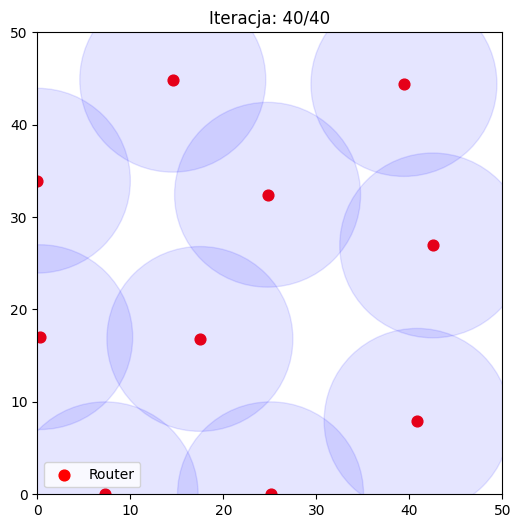

In [ ]:
# Rozpisanie rozwiązania
best_pos, best_score, history = pso(wifi_coverage_score, bounds, num_routers, max_iter)

# Przygotowanie wykresu
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
scat = ax.scatter([], [], c = 'red', s = 60, label = 'Router')
circles = [Circle((0, 0), coverage_radius, color = 'blue', alpha = 0.1) for _ in range(num_routers)]
for c in circles:
  ax.add_patch(c)
ax.set_title(f'Iteracja: 0/{max_iter}')
ax.legend()

# Poklatkowe przygotowanie animacji
def update(frame):
  current_positions = history[frame][0].reshape(num_routers, 2)
  scat.set_offsets(current_positions)
  for i, (x, y) in enumerate(current_positions):
    circles[i].center = (x, y)
  ax.set_title(f'Iteracja: {frame + 1}/{max_iter}')
  return [scat] + circles

# Parametry animacji
anim = FuncAnimation(fig, update, frames = len(history), interval = 300, blit = True, repeat = False)

# Wywołanie wyniku (prezentacja)
HTML(anim.to_jshtml())

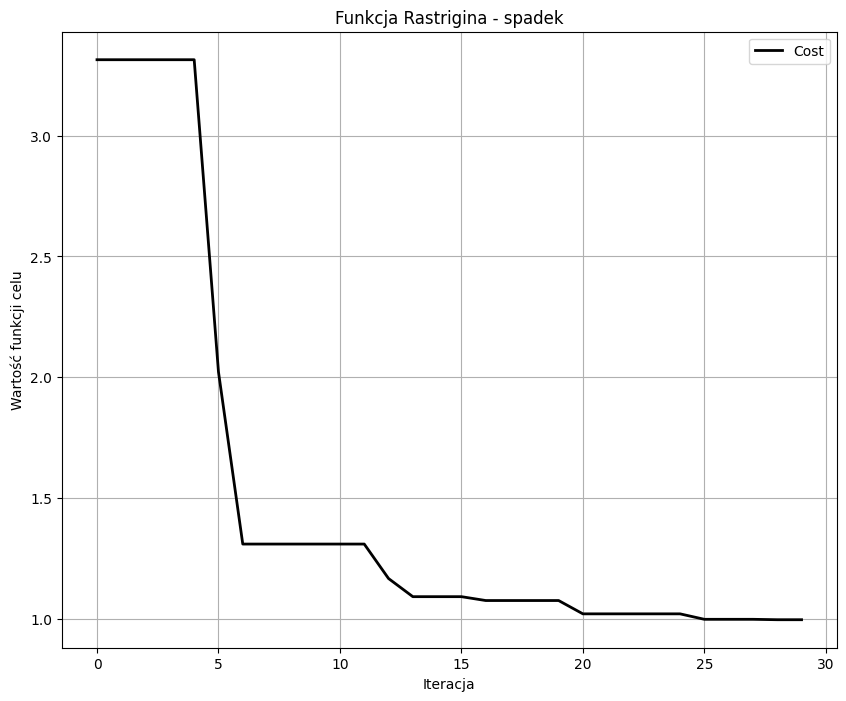

In [ ]:
# Wykres zbieżności
from pyswarms.utils.plotters import plot_cost_history
plot_cost_history(optimizer.cost_history)
plt.title("Funkcja Rastrigina - spadek")
plt.xlabel("Iteracja")
plt.ylabel("Wartość funkcji celu")
plt.grid(True)
plt.show()